# 06 - Capacity Analysis

Identifies stations where demand is approaching or exceeding available capacity, using the composite `capacity_risk_score` defined in `python/analysis.py`:

```
capacity_risk_score = 0.4*utilization_norm + 0.35*wait_norm + 0.25*sessions_per_charger_norm
```
All three inputs are min-max normalized across stations before weighting.

In [1]:
import sys, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '../python')
import analysis as an

df = pd.read_csv('../data/processed/ev_charging_features.csv')
station_util, _, _ = an.station_utilization_analysis(df)
capacity = an.capacity_analysis(df, station_util)
capacity.head(10)[['station_name','city','avg_utilization_rate','avg_wait_time','sessions_per_charger','capacity_risk_score','capacity_risk','expansion_priority']]

,station_name,city,avg_utilization_rate,avg_wait_time,sessions_per_charger,capacity_risk_score,capacity_risk,expansion_priority
0,Whitefield Ev Hub 1035,Bengaluru,0.355406,13.755446,1111.000000,0.9635,CRITICAL,HIGH
1,Jayanagar Ev Hub 1047,Bengaluru,0.363281,13.072043,1116.000000,0.9440,CRITICAL,HIGH
2,Viman Nagar Ev Hub 1060,Pune,0.132128,14.326497,840.333333,0.6483,HIGH,MEDIUM
3,Kothrud Ev Hub 1055,Pune,0.133547,13.982248,875.000000,0.6428,HIGH,MEDIUM
4,Borivali Ev Hub 1031,Mumbai,0.346774,9.862016,516.000000,0.6392,HIGH,MEDIUM
5,Dwarka Ev Hub 1005,Delhi,0.181243,11.397076,615.500000,0.5257,HIGH,MEDIUM
6,Bandra Ev Hub 1022,Mumbai,0.178866,11.372188,564.500000,0.5096,HIGH,MEDIUM
7,Bandra Ev Hub 1021,Mumbai,0.080987,12.697094,571.200000,0.4488,MEDIUM,LOW
8,Thane Ev Hub 1030,Mumbai,0.082422,12.416390,601.600000,0.4452,MEDIUM,LOW
9,Baner Ev Hub 1061,Pune,0.081607,12.122450,564.800000,0.4224,MEDIUM,LOW


## Capacity risk tier distribution

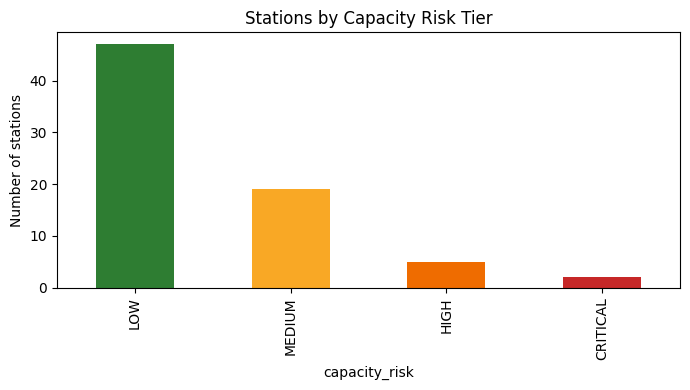

In [2]:
counts = capacity['capacity_risk'].value_counts().reindex(['LOW','MEDIUM','HIGH','CRITICAL']).fillna(0)
counts.plot(kind='bar', color=['#2E7D32','#F9A825','#EF6C00','#C62828'], figsize=(7,4), title='Stations by Capacity Risk Tier')
plt.ylabel('Number of stations'); plt.tight_layout(); plt.show()

## Utilization vs waiting time (bubble = sessions per charger)
Confirms the core hypothesis: stations with higher utilization tend to have longer waits.

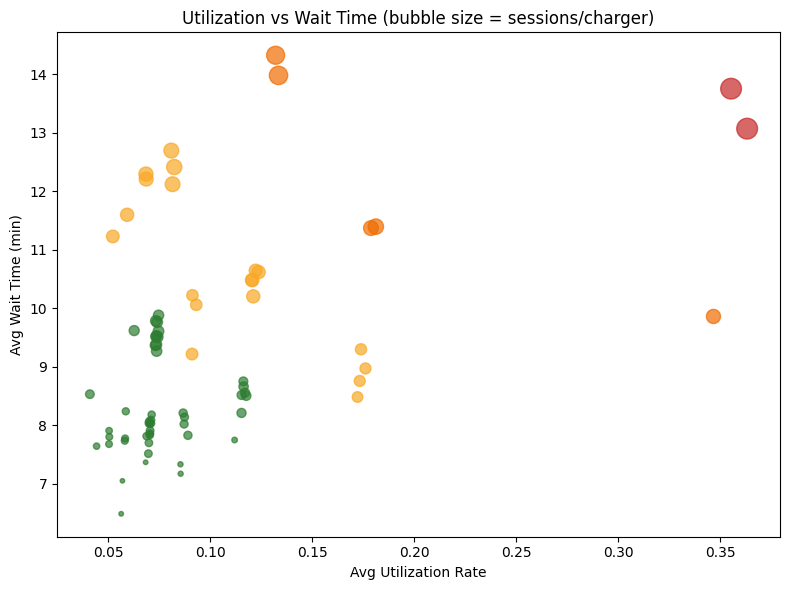

Correlation (utilization vs wait time): 0.443


In [3]:
plt.figure(figsize=(8,6))
colors = capacity['capacity_risk'].map({'LOW':'#2E7D32','MEDIUM':'#F9A825','HIGH':'#EF6C00','CRITICAL':'#C62828'})
plt.scatter(capacity['avg_utilization_rate'], capacity['avg_wait_time'], s=capacity['sessions_per_charger']/5, c=colors, alpha=0.7)
plt.xlabel('Avg Utilization Rate'); plt.ylabel('Avg Wait Time (min)')
plt.title('Utilization vs Wait Time (bubble size = sessions/charger)'); plt.tight_layout(); plt.show()
print('Correlation (utilization vs wait time):', round(capacity['avg_utilization_rate'].corr(capacity['avg_wait_time']), 3))

## Stations recommended for expansion (HIGH priority)

In [4]:
capacity[capacity['expansion_priority']=='HIGH'][['station_name','city','avg_utilization_rate','avg_wait_time','sessions_per_charger','capacity_risk_score']]

,station_name,city,avg_utilization_rate,avg_wait_time,sessions_per_charger,capacity_risk_score
0,Whitefield Ev Hub 1035,Bengaluru,0.355406,13.755446,1111.0,0.9635
1,Jayanagar Ev Hub 1047,Bengaluru,0.363281,13.072043,1116.0,0.9440


## Underutilized stations (expansion NOT justified)

In [5]:
low_util = station_util[station_util['utilization_classification']=='LOW'].sort_values('avg_utilization_rate')
print(f'{len(low_util)} stations at LOW utilization')
low_util.head(10)[['station_name','city','avg_utilization_rate','total_sessions']]

64 stations at LOW utilization


,station_name,city,avg_utilization_rate,total_sessions
43,Indiranagar Ev Hub 1044,Bengaluru,0.041073,1730
63,Hitech City Ev Hub 1064,Hyderabad,0.044357,841
3,Dwarka Ev Hub 1004,Delhi,0.050460,817
14,Karol Bagh Ev Hub 1015,Delhi,0.050497,772
37,Koramangala Ev Hub 1038,Bengaluru,0.050588,835
10,Saket Ev Hub 1011,Delhi,0.052305,3299
40,Indiranagar Ev Hub 1041,Bengaluru,0.056416,328
0,Connaught Place Ev Hub 1001,Delhi,0.057032,309
26,Thane Ev Hub 1027,Mumbai,0.058179,754
69,Kukatpally Ev Hub 1070,Hyderabad,0.058349,752
